<a href="https://colab.research.google.com/github/Striver29/CrossEnrich/blob/main/CrossEnrich_v0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Phase 1: Hardcoded data collection**

In [1]:
!pip install gprofiler-official matplotlib seaborn --quiet
print("done")

done


In [2]:
from gprofiler import GProfiler
import pandas as pd

In [3]:
gene_list = ["TP53", "MDM2", "CDKN1A", "BAX", "BBC3", "PMAIP1", "GADD45A", "GADD45B",
"SESN1", "SESN2", "RRM2B", "DRAM1", "FAS", "TNFRSF10B", "APAF1",
"CASP3", "CASP9", "CYCS", "PTEN", "ATM", "ATR", "BRCA1", "BRCA2"]

print(len(gene_list))
print(gene_list)

23
['TP53', 'MDM2', 'CDKN1A', 'BAX', 'BBC3', 'PMAIP1', 'GADD45A', 'GADD45B', 'SESN1', 'SESN2', 'RRM2B', 'DRAM1', 'FAS', 'TNFRSF10B', 'APAF1', 'CASP3', 'CASP9', 'CYCS', 'PTEN', 'ATM', 'ATR', 'BRCA1', 'BRCA2']


In [4]:
gp = GProfiler()
results = gp.profile(gene_list, organism="hsapiens", no_evidences=False) #no_evidences=False is set to show intersections
results = pd.DataFrame(results)
print(results.shape)

(571, 16)


In [5]:
results.head()

,description,effective_domain_size,intersection_size,intersections,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size,evidences
0,p53 signaling pathway,8716,20,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",p53 signaling pathway,KEGG:04115,4.790777e-39,[KEGG:00000],0.909091,query_1,22,0.266667,True,KEGG,75,"[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
1,DNA damage response,8899,19,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",DNA damage response,WP:WP707,6.570686e-36,[WP:000000],0.826087,query_1,23,0.275362,True,WP,69,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."
2,miRNA regulation of DNA damage response,8899,19,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",miRNA regulation of DNA damage response,WP:WP1530,2.257520e-35,[WP:000000],0.826087,query_1,23,0.260274,True,WP,73,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."
3,Platinum drug resistance,8716,13,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, FAS, A...",Platinum drug resistance,KEGG:01524,1.238753e-20,[KEGG:00000],0.590909,query_1,22,0.175676,True,KEGG,74,"[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
4,miRNA regulation of p53 pathway in prostate ca...,8899,11,"[TP53, MDM2, BAX, BBC3, PMAIP1, TNFRSF10B, APA...",miRNA regulation of p53 pathway in prostate ca...,WP:WP3982,2.331874e-20,[WP:000000],0.478261,query_1,23,0.354839,True,WP,31,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."


In [6]:
print(results["source"].unique())

<StringArray>
[ 'KEGG',    'WP',  'REAC', 'GO:BP',    'HP', 'GO:CC', 'MIRNA', 'CORUM',
 'GO:MF',    'TF',   'HPA']
Length: 11, dtype: str


**Note: We treat GO as three separate databases:**

GO:BP (Biological Processes)

GO:CC (Cellular Component)

GO:MF (Molecular Function)

For interpretability, GO is kept split into GO:BP, GO:CC, and GO:MF. In this notebook we also keep WP, giving six sources in the exploratory comparison: GO:BP, GO:CC, GO:MF, KEGG, REAC, and WP.

#**Phase 2: Source filtering**




In [7]:
df_gobp = results[results["source"] == "GO:BP"]
df_gocc = results[results["source"] == "GO:CC"]
df_gomf = results[results["source"] == "GO:MF"]
df_kegg = results[results["source"] == "KEGG"]
df_reac = results[results["source"] == "REAC"]
df_wp = results[results["source"] == "WP"]

The code below keeps only terms marked significant by g:Profiler after multiple-testing correction.

In [8]:
df_gobp = df_gobp[df_gobp["significant"] == True]
df_gocc = df_gocc[df_gocc["significant"] == True]
df_gomf = df_gomf[df_gomf["significant"] == True]
df_kegg = df_kegg[df_kegg["significant"] == True]
df_reac = df_reac[df_reac["significant"] == True]
df_wp = df_wp[df_wp["significant"] == True]

In [9]:
print("GO:BP ",df_gobp.shape)
print("GO:CC ",df_gocc.shape)
print("GO:MF ", df_gomf.shape)
print("KEGG ", df_kegg.shape)
print("REAC ", df_reac.shape)
print("WP ", df_wp.shape)

GO:BP  (209, 16)
GO:CC  (12, 16)
GO:MF  (10, 16)
KEGG  (54, 16)
REAC  (76, 16)
WP  (69, 16)


#**Phase 3: Consistency and Metrics**




**Term Jaccard**



In [10]:
#mock example of two databases and direct name matching.

df_kegg_set = set(df_kegg["name"])
df_reac_set = set(df_reac["name"])

union = df_kegg_set.union(df_reac_set)
intersection = df_kegg_set.intersection(df_reac_set)

jaccard = len(intersection)/len(union)
print(jaccard)

0.007751937984496124


In [11]:
print(intersection)

#only one direct match

{'Apoptosis'}


In [12]:
# Import baseline metric helpers from the package instead of redefining them here.
from pathlib import Path
import sys

baseline_src = Path.cwd().resolve().parent / "src"
if not baseline_src.exists():
    baseline_src = Path.cwd().resolve() / "src"

if str(baseline_src) not in sys.path:
    sys.path.insert(0, str(baseline_src))

from crossenrich.baseline import (
    build_gene_jaccard_matrix,
    build_spearman_matrix,
    build_term_jaccard_matrix,
    gene_jaccard_score,
    spearman_score,
    term_jaccard_score,
)


def prepare_baseline_frame(frame):
    prepared = frame.copy()
    if "intersections" in prepared.columns and "intersection_genes" not in prepared.columns:
        prepared["intersection_genes"] = prepared["intersections"]
    return prepared


In [13]:
databases = [
    ("GO:BP", prepare_baseline_frame(df_gobp)),
    ("GO:CC", prepare_baseline_frame(df_gocc)),
    ("GO:MF", prepare_baseline_frame(df_gomf)),
    ("KEGG", prepare_baseline_frame(df_kegg)),
    ("REAC", prepare_baseline_frame(df_reac)),
    ("WP", prepare_baseline_frame(df_wp)),
]

results_by_source = {name: df for name, df in databases}
matrix_df = build_term_jaccard_matrix(results_by_source)

print(matrix_df)


         GO:BP  GO:CC  GO:MF      KEGG      REAC        WP
GO:BP      NaN    0.0    0.0  0.000000  0.000000  0.003610
GO:CC  0.00000    NaN    0.0  0.000000  0.000000  0.000000
GO:MF  0.00000    0.0    NaN  0.000000  0.000000  0.000000
KEGG   0.00000    0.0    0.0       NaN  0.007752  0.051282
REAC   0.00000    0.0    0.0  0.007752       NaN  0.006944
WP     0.00361    0.0    0.0  0.051282  0.006944       NaN


**Results indicate that direct name comparison yeild nearly zero consistency**

# **Gene-level Jaccard**

In [14]:
# Gene-level agreement now comes from the package baseline module.
print("Imported gene_jaccard_score from crossenrich.baseline")


In [15]:
print(gene_jaccard_score(results_by_source["KEGG"], results_by_source["REAC"]))


0.69604630119336


In [16]:
# Building the gene-level agreement matrix over the databases.
matrix_df_gene_level = build_gene_jaccard_matrix(results_by_source)

print(matrix_df_gene_level)


       GO:BP     GO:CC     GO:MF      KEGG      REAC        WP
GO:BP    NaN  0.651406  0.552613  0.641098  0.654144  0.660229
GO:CC    NaN       NaN  0.563570  0.697826  0.683779  0.676864
GO:MF    NaN       NaN       NaN  0.566071  0.625550  0.557746
KEGG     NaN       NaN       NaN       NaN  0.696046  0.815816
REAC     NaN       NaN       NaN       NaN       NaN  0.781863
WP       NaN       NaN       NaN       NaN       NaN       NaN


# **Spearman Correlation**

In [17]:
# Spearman correlation is also imported from the package baseline module.
print("Imported spearman_score from crossenrich.baseline")


In [18]:
print(spearman_score(results_by_source["KEGG"], results_by_source["REAC"]))


0.40162577014679074


In [19]:
matrix_df_spearman = build_spearman_matrix(results_by_source)

print(matrix_df_spearman)


          GO:BP     GO:CC     GO:MF      KEGG      REAC        WP
GO:BP       NaN  0.086708  0.201692  0.552718  0.516021  0.595585
GO:CC  0.086708       NaN  0.000000 -0.065290 -0.317887 -0.202784
GO:MF  0.201692  0.000000       NaN  0.811679  0.600000  0.285714
KEGG   0.552718 -0.065290  0.811679       NaN  0.401626  0.606257
REAC   0.516021 -0.317887  0.600000  0.401626       NaN  0.417881
WP     0.595585 -0.202784  0.285714  0.606257  0.417881       NaN


# **Phase 4: Using the reusable CrossEnrich package**

The cells below take the real `results` DataFrame returned by g:Profiler and pass it through the reusable package modules in `src/crossenrich/`. We start with a top-ranked demo subset so the semantic similarity and cluster outputs stay readable. The package itself uses the benchmark-selected default weights and threshold, and those defaults should be the standard starting point unless you are intentionally exploring alternative settings.

In [20]:
from pathlib import Path
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

repo_src = Path.cwd().resolve().parent / "src"
if not repo_src.exists():
    repo_src = Path.cwd().resolve() / "src"

if str(repo_src) not in sys.path:
    sys.path.insert(0, str(repo_src))

import crossenrich
import crossenrich.pipeline as pipeline
import crossenrich.reporting as reporting
import crossenrich.visuals as visuals
import crossenrich.network as network

importlib.reload(network)
importlib.reload(reporting)
importlib.reload(visuals)
importlib.reload(pipeline)
importlib.reload(crossenrich)

from crossenrich.pipeline import run_crossenrich_pipeline
from crossenrich.reporting import (
    build_database_pair_summary,
    build_run_summary_row,
    extract_source_specific_clusters,
    extract_top_consensus_clusters,
)
from crossenrich.network import build_cluster_network, cluster_network_to_frame
from crossenrich.visuals import (
    plot_cluster_network,
    plot_database_agreement_panels,
    plot_score_heatmap,
    plot_source_pair_ranking,
    plot_top_consensus_clusters,
    save_default_visuals,
)

print("Using src path:", repo_src)
print(crossenrich.__file__)


from crossenrich.semantic import build_semantic_similarity_matrix


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using src path: /Users/ranaezzeddine/Desktop/CrossEnrich/src
/Users/ranaezzeddine/Desktop/CrossEnrich/src/crossenrich/__init__.py


In [21]:
standardized = crossenrich.standardize_results_frame(results)

semantic_demo_results = (
    standardized.sort_values("p_value")
    .groupby("canonical_source", group_keys=False)
    .head(80)
    .reset_index(drop=True)
)

print("Standardized shape:", standardized.shape)
print("Semantic demo shape:", semantic_demo_results.shape)
display(semantic_demo_results[["canonical_source", "name", "p_value", "rank_within_source"]])


Standardized shape: (430, 23)
Small demo shape: (301, 23)


,canonical_source,name,p_value,rank_within_source
0,KEGG,p53 signaling pathway,4.790777e-39,1
1,WP,DNA damage response,6.570686e-36,1
2,WP,miRNA regulation of DNA damage response,2.257520e-35,2
3,KEGG,Platinum drug resistance,1.238753e-20,2
4,WP,miRNA regulation of p53 pathway in prostate ca...,2.331874e-20,3
...,...,...,...,...
296,REAC,Dimerization of procaspase-8,4.974757e-02,58
297,REAC,CASP8 activity is inhibited,4.974757e-02,58
298,REAC,Regulation by c-FLIP,4.974757e-02,58
299,REAC,Caspase activation via Dependence Receptors in...,4.974757e-02,58


In [22]:
outputs = run_crossenrich_pipeline(
    semantic_demo_results,
    significant_only=False,
    semantic_similarity_threshold=0.25,
)

print("Cross-database semantic similarity matrix used in the package workflow:")
display(outputs.semantic_similarity_matrix.round(2))

print("Clustered term table:")
display(
    outputs.clustered_terms[[
        "canonical_source",
        "name",
        "standardized_name",
        "cluster_id",
        "cluster_label",
        "semantic_similarity_max",
    ]].sort_values(["cluster_id", "canonical_source"])
)

print("Database-level cluster consistency matrix:")
display(outputs.cluster_consistency_matrix.round(2))

print("Validation summary:")
print(outputs.cluster_consistency_validation)
print("Cluster summary:")
print(outputs.cluster_summary)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 75576.47it/s]
BertModel LOAD REPORT from: allenai/specter
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Term-term similarity matrix:


,0,1,2,3,4,5,6,7,8,9,...,291,292,293,294,295,296,297,298,299,300
0,1.00,0.35,0.35,0.00,0.55,0.38,0.50,0.27,0.28,0.49,...,0.25,0.27,0.24,0.25,0.28,0.25,0.26,0.27,0.25,0.25
1,0.35,1.00,0.00,0.31,0.00,0.34,0.30,0.38,0.39,0.00,...,0.25,0.31,0.00,0.00,0.29,0.24,0.26,0.26,0.25,0.00
2,0.35,0.00,1.00,0.29,0.00,0.46,0.31,0.36,0.36,0.00,...,0.26,0.28,0.00,0.00,0.29,0.26,0.25,0.36,0.25,0.00
3,0.00,0.31,0.29,1.00,0.31,0.27,0.27,0.25,0.25,0.27,...,0.22,0.25,0.21,0.23,0.27,0.22,0.23,0.25,0.22,0.21
4,0.55,0.00,0.00,0.31,1.00,0.41,0.39,0.29,0.30,0.00,...,0.28,0.26,0.00,0.00,0.28,0.28,0.25,0.37,0.27,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,0.25,0.24,0.26,0.22,0.28,0.00,0.27,0.26,0.26,0.26,...,0.00,0.00,0.22,0.23,0.27,1.00,0.00,0.00,0.00,0.21
297,0.26,0.26,0.25,0.23,0.25,0.00,0.23,0.23,0.24,0.26,...,0.00,0.00,0.19,0.22,0.23,0.00,1.00,0.00,0.00,0.23
298,0.27,0.26,0.36,0.25,0.37,0.00,0.26,0.28,0.29,0.29,...,0.00,0.00,0.24,0.27,0.27,0.00,0.00,1.00,0.00,0.22
299,0.25,0.25,0.25,0.22,0.27,0.00,0.30,0.27,0.28,0.23,...,0.00,0.00,0.21,0.21,0.27,0.00,0.00,0.00,1.00,0.21


Clustered term table:


,canonical_source,name,standardized_name,cluster_id,cluster_label,semantic_similarity_max
176,REAC,Impaired BRCA2 binding to RAD51,impaired brca2 binding to rad51,0,impaired brca2 binding to rad51,0.394611
278,WP,Peroxiredoxin 2 induced ovarian failure,peroxiredoxin 2 induced ovarian failure,1,peroxiredoxin 2 induced ovarian failure,0.318747
193,KEGG,Pathogenic Escherichia coli infection,pathogenic escherichia coli infection,2,pathogenic escherichia coli infection,0.444737
297,REAC,CASP8 activity is inhibited,casp8 activity is inhibited,3,casp8 activity is inhibited,0.433419
138,GO:BP,response to stimulus,response to stimulus,4,response to stimulus,0.432573
...,...,...,...,...,...,...
122,WP,Cell cycle,cell cycle,66,cell cycle,1.000000
169,WP,G1 to S cell cycle control,g1 to s cell cycle control,66,cell cycle,0.678349
175,WP,Head and neck squamous cell carcinoma,head and neck squamous cell carcinoma,66,cell cycle,0.547250
247,WP,T cell activation SARS CoV 2,t cell activation sars cov 2,66,cell cycle,0.460793


Database-level cluster consistency matrix:


,GO:BP,GO:CC,GO:MF,KEGG,REAC,WP
GO:BP,1.00,0.23,0.19,0.25,0.63,0.41
GO:CC,0.23,1.00,0.29,0.18,0.22,0.19
GO:MF,0.19,0.29,1.00,0.13,0.18,0.12
KEGG,0.25,0.18,0.13,1.00,0.40,0.65
REAC,0.63,0.22,0.18,0.40,1.00,0.55
WP,0.41,0.19,0.12,0.65,0.55,1.00


Validation summary:
{'is_valid': True, 'issues': [], 'shape': (6, 6)}
Cluster summary:
{'term_count': 301, 'cluster_count': 68, 'singleton_cluster_count': 18, 'multi_source_cluster_count': 50, 'mean_cluster_size': 4.426470588235294}


In [23]:
pair_summary = build_database_pair_summary(outputs)
top_clusters = extract_top_consensus_clusters(outputs.clustered_terms, top_n=10)
source_specific_clusters = extract_source_specific_clusters(outputs.clustered_terms, top_n=10)
run_summary = build_run_summary_row("TP53-small", outputs)

graph = build_cluster_network(outputs.clustered_terms, min_edge_weight=0.15)
graph_summary = cluster_network_to_frame(graph)

print("Run summary")
display(pd.DataFrame([run_summary]))

print("Database-pair summary")
display(pair_summary)

print("Top consensus clusters")
display(top_clusters)

print("Source-specific clusters")
display(source_specific_clusters)

print("Cluster-network node summary")
display(graph_summary)



Run summary


,run_name,source_count,term_count,cluster_count,multi_source_cluster_count,singleton_cluster_count,mean_cluster_size,strongest_term_pair,strongest_term_score,strongest_gene_pair,strongest_gene_score,strongest_semantic_pair,strongest_semantic_score,cluster_matrix_valid
0,TP53-small,6,301,68,50,18,4.426471,KEGG-WP,0.051282,KEGG-WP,0.815816,KEGG-WP,0.652174,True


Database-pair summary


,source_pair,source_a,source_b,term_jaccard,gene_jaccard,spearman,cluster_consistency,semantic_minus_gene,semantic_minus_term,strongest_signal
0,KEGG-WP,KEGG,WP,0.051282,0.815816,0.606257,0.652174,-0.163642,0.600892,gene
1,REAC-GO:BP,REAC,GO:BP,0.000000,0.629150,0.622179,0.629630,0.000479,0.629630,semantic
2,WP-REAC,WP,REAC,0.006944,0.694207,0.467222,0.545455,-0.148752,0.538510,gene
3,WP-GO:BP,WP,GO:BP,0.006757,0.627662,0.732153,0.406780,-0.220883,0.400023,rank
4,KEGG-REAC,KEGG,REAC,0.007752,0.696046,0.401626,0.396552,-0.299495,0.388800,gene
5,GO:CC-GO:MF,GO:CC,GO:MF,0.000000,0.563570,0.000000,0.285714,-0.277856,0.285714,gene
6,KEGG-GO:BP,KEGG,GO:BP,0.000000,0.655292,0.375283,0.253968,-0.401323,0.253968,gene
7,GO:BP-GO:CC,GO:BP,GO:CC,0.000000,0.686358,0.163141,0.232558,-0.453800,0.232558,gene
8,REAC-GO:CC,REAC,GO:CC,0.000000,0.759131,0.123629,0.222222,-0.536909,0.222222,gene
9,WP-GO:CC,WP,GO:CC,0.000000,0.575574,-0.221295,0.190476,-0.385098,0.190476,gene


Top consensus clusters


,cluster_id,cluster_label,source_count,term_count,sources,representative_terms,representative_genes,mean_semantic_similarity_max
0,66,cell cycle,6,34,"GO:BP, GO:CC, GO:MF, KEGG, REAC, WP",programmed cell death | cell death | Small cel...,"TP53, CDKN1A, ATM, BAX, GADD45A",0.638032
1,62,integrated cancer pathway,6,22,"GO:BP, GO:CC, GO:MF, KEGG, REAC, WP",Integrated cancer pathway | intracellular sign...,"TP53, BAX, CDKN1A, ATM, MDM2",0.577440
2,50,positive regulation of neuron apoptotic process,6,8,"GO:BP, GO:CC, GO:MF, KEGG, REAC, WP",positive regulation of neuron apoptotic proces...,"BAX, TP53, BBC3, CASP9, FAS",0.467768
3,61,melanoma,6,7,"GO:BP, GO:CC, GO:MF, KEGG, REAC, WP",cellular response to environmental stimulus | ...,"MDM2, TP53, CDKN1A, PTEN, BRCA1",0.607239
4,54,p53 signaling pathway,5,23,"GO:BP, GO:CC, KEGG, REAC, WP",p53 signaling pathway | miRNA regulation of p5...,"TP53, MDM2, BAX, CDKN1A, PTEN",0.563467
5,51,apoptosis,5,17,"GO:BP, GO:CC, KEGG, REAC, WP",Apoptosis | Apoptosis modulation and signaling...,"CASP9, APAF1, CASP3, CYCS, BAX",0.624561
6,64,transcriptional regulation by tp53,5,9,"GO:BP, GO:MF, KEGG, REAC, WP",Transcriptional Regulation by TP53 | p53 trans...,"TP53, ATM, MDM2, BAX, CDKN1A",0.498694
7,48,regulation of apoptotic process,5,5,"GO:BP, GO:CC, KEGG, REAC, WP",regulation of apoptotic process | Amyotrophic ...,"APAF1, CASP9, BAX, CASP3, TP53",0.644636
8,41,dna damage response,4,24,"GO:BP, GO:CC, REAC, WP",DNA damage response | miRNA regulation of DNA ...,"ATM, ATR, BRCA1, TP53, BRCA2",0.575546
9,63,androgen receptor network in prostate cancer,4,8,"GO:BP, KEGG, REAC, WP",Androgen receptor network in prostate cancer |...,"MDM2, TP53, ATM, CDKN1A, ATR",0.548825


Source-specific clusters


,cluster_id,cluster_label,source,term_count,representative_terms,representative_genes,mean_semantic_similarity_max
0,9,defective homologous recombination repair hrr ...,REAC,1,Defective homologous recombination repair (HRR...,"ATM, BRCA1, BRCA2",0.582651
1,18,defective hdr through homologous recombination...,REAC,1,Defective HDR through Homologous Recombination...,"ATM, BRCA1, BRCA2",0.511386
2,20,regulation of response to stimulus,GO:BP,1,regulation of response to stimulus,"APAF1, ATM, ATR, BAX, BBC3",0.468526
3,8,cellular response to stimulus,GO:BP,1,cellular response to stimulus,"APAF1, ATM, ATR, BAX, BBC3",0.467550
4,17,cellular response to abiotic stimulus,GO:BP,1,cellular response to abiotic stimulus,"ATM, ATR, BAX, BBC3, BRCA1",0.456079
5,36,kaposi sarcoma associated herpesvirus infection,KEGG,1,Kaposi sarcoma-associated herpesvirus infection,"BAX, CASP3, CASP9, CDKN1A, CYCS",0.451599
6,2,pathogenic escherichia coli infection,KEGG,1,Pathogenic Escherichia coli infection,"BAX, CASP3, CASP9, CYCS, FAS",0.444737
7,3,casp8 activity is inhibited,REAC,1,CASP8 activity is inhibited,"FAS, TNFRSF10B",0.433419
8,4,response to stimulus,GO:BP,1,response to stimulus,"APAF1, ATM, ATR, BAX, BBC3",0.432573
9,15,positive regulation of response to stimulus,GO:BP,1,positive regulation of response to stimulus,"APAF1, ATM, ATR, BAX, BBC3",0.431442


Cluster-network node summary


,cluster_id,cluster_label,source_count,term_count,gene_count,sources,degree
0,66,cell cycle,6,34,23,"GO:BP, GO:CC, GO:MF, KEGG, REAC, WP",49
1,62,integrated cancer pathway,6,22,23,"GO:BP, GO:CC, GO:MF, KEGG, REAC, WP",49
2,61,melanoma,6,7,17,"GO:BP, GO:CC, GO:MF, KEGG, REAC, WP",49
3,54,p53 signaling pathway,5,23,22,"GO:BP, GO:CC, KEGG, REAC, WP",49
4,48,regulation of apoptotic process,5,5,17,"GO:BP, GO:CC, KEGG, REAC, WP",49
5,41,dna damage response,4,24,22,"GO:BP, GO:CC, REAC, WP",49
6,63,androgen receptor network in prostate cancer,4,8,13,"GO:BP, KEGG, REAC, WP",49
7,59,cellular response to radiation,4,5,16,"GO:BP, KEGG, REAC, WP",49
8,45,epstein barr virus infection,4,5,22,"GO:BP, KEGG, REAC, WP",49
9,28,tp53 regulates transcription of genes involved...,4,5,15,"GO:BP, KEGG, REAC, WP",49


## Database Agreement Panels
This figure shows the four main agreement views side by side: direct term overlap, gene-level Jaccard, Spearman rank correlation, and semantic cluster consistency. It helps show why exact-name agreement alone is not enough and why the semantic layer adds value.

(<Figure size 1400x1100 with 8 Axes>,
 array([[<Axes: title={'center': 'Direct Term Overlap'}>,
         <Axes: title={'center': 'Gene-Level Jaccard'}>],
        [<Axes: title={'center': 'Spearman Correlation'}>,
         <Axes: title={'center': 'Cluster-Based Database Consistency'}>]],
       dtype=object))

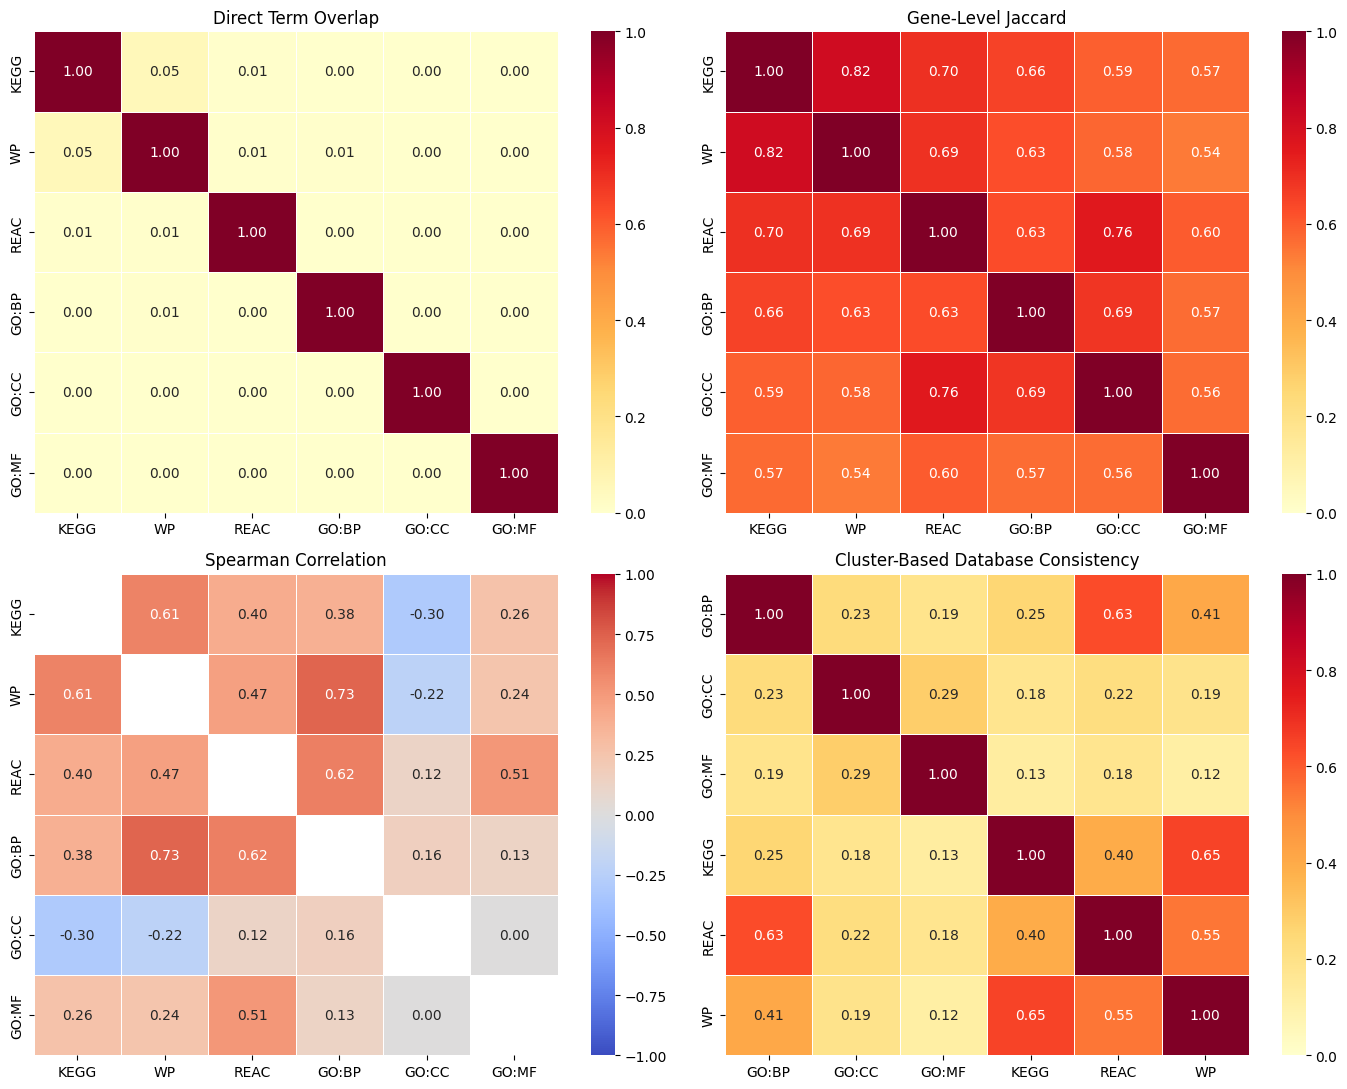

In [24]:
plot_database_agreement_panels(outputs)


## Source-Pair Ranking
This ranking plot summarizes which database pairs show the strongest semantic cluster agreement. It gives a faster read than scanning the full matrix when the goal is to identify the most consistent source pairs.

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Top Source Pairs by Semantic Cluster Agreement'}, xlabel='Cluster consistency', ylabel='Source pair'>)

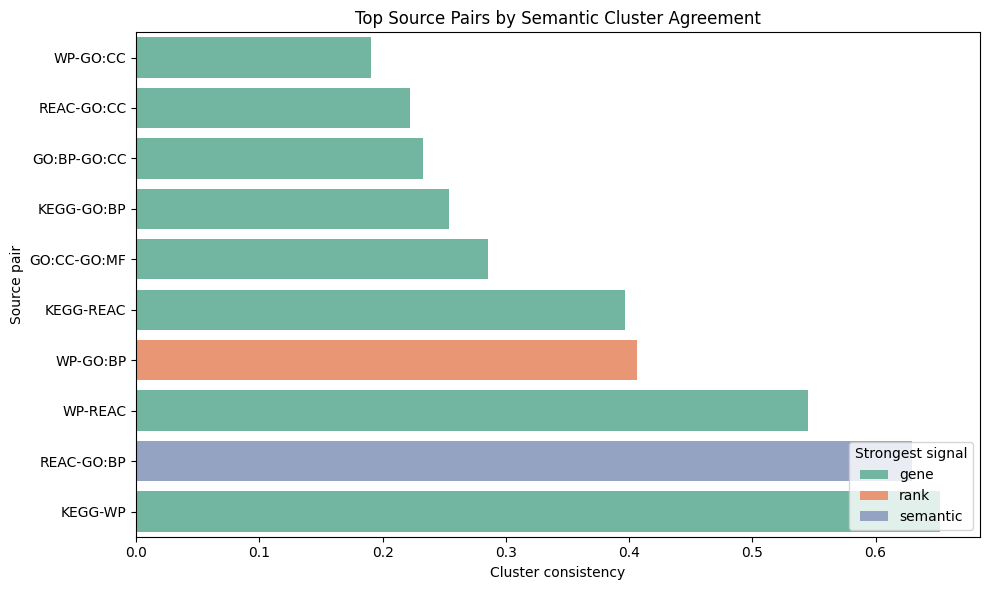

In [25]:
plot_source_pair_ranking(outputs, top_n=10)


## Top Consensus Clusters
This plot highlights the strongest multi-source semantic clusters. These are the shared biological themes that appear across more than one enrichment database, which makes them especially useful for interpretation.

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Top Consensus Clusters'}, xlabel='Number of terms in cluster', ylabel='Cluster label'>)

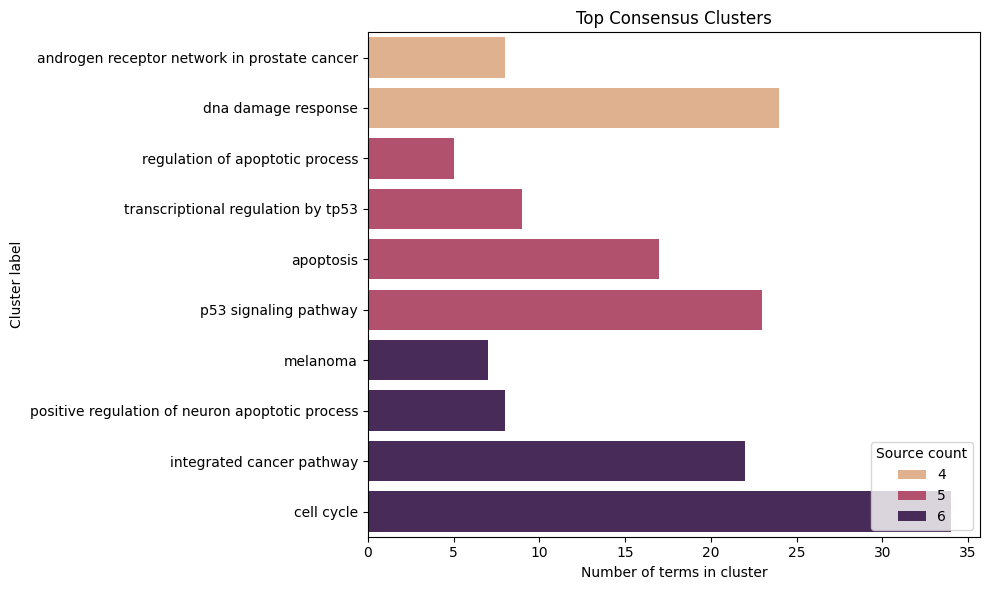

In [26]:
plot_top_consensus_clusters(outputs.clustered_terms, top_n=10)


## Cluster Network
This network shows how semantic clusters connect through shared genes. You can either view the full multi-source network or restrict it to specific databases so the user can focus on relationships such as KEGG + REAC or KEGG + WP without the full graph turning into a hairball.

(<Figure size 1200x900 with 2 Axes>,
 <Axes: title={'center': 'Cluster-Level Enrichment Network'}>)

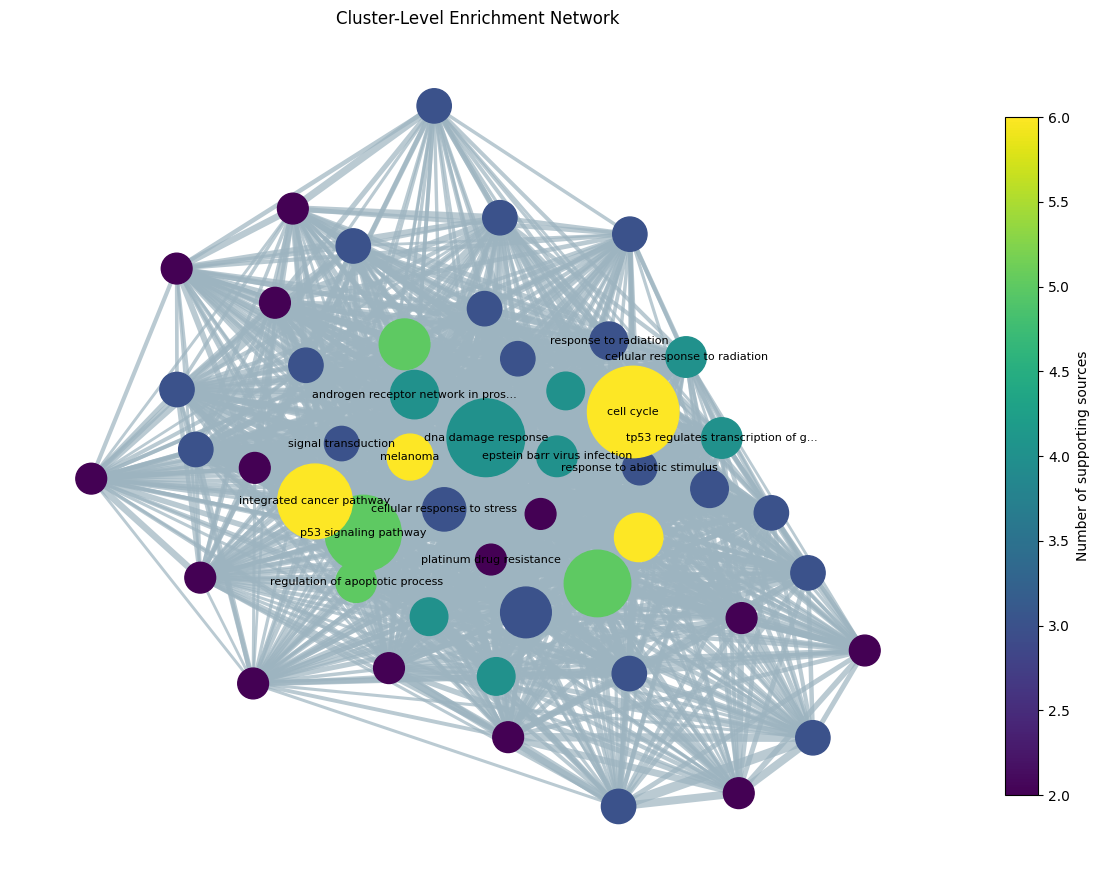

In [27]:
# Overall cluster network
plot_cluster_network(outputs.clustered_terms, min_edge_weight=0.15)

# Focused cluster network for selected databases
selected_sources = ("KEGG", "REAC")
plot_cluster_network(
    outputs.clustered_terms,
    selected_sources=selected_sources,
    min_edge_weight=0.15,
)

selected_graph = build_cluster_network(
    outputs.clustered_terms,
    selected_sources=selected_sources,
    min_edge_weight=0.15,
)
display(cluster_network_to_frame(selected_graph))


## Semantic Similarity Matrices (Diagnostic vs Workflow View)
The package workflow uses a cross-database semantic matrix so clustering focuses on agreement across different sources rather than within-source near-duplicates. The figure below also shows an all-pairs diagnostic matrix, which is useful for checking that the semantic layer produces meaningful structure overall, including within-source relationships.

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Semantic Similarity Matrix'}>)

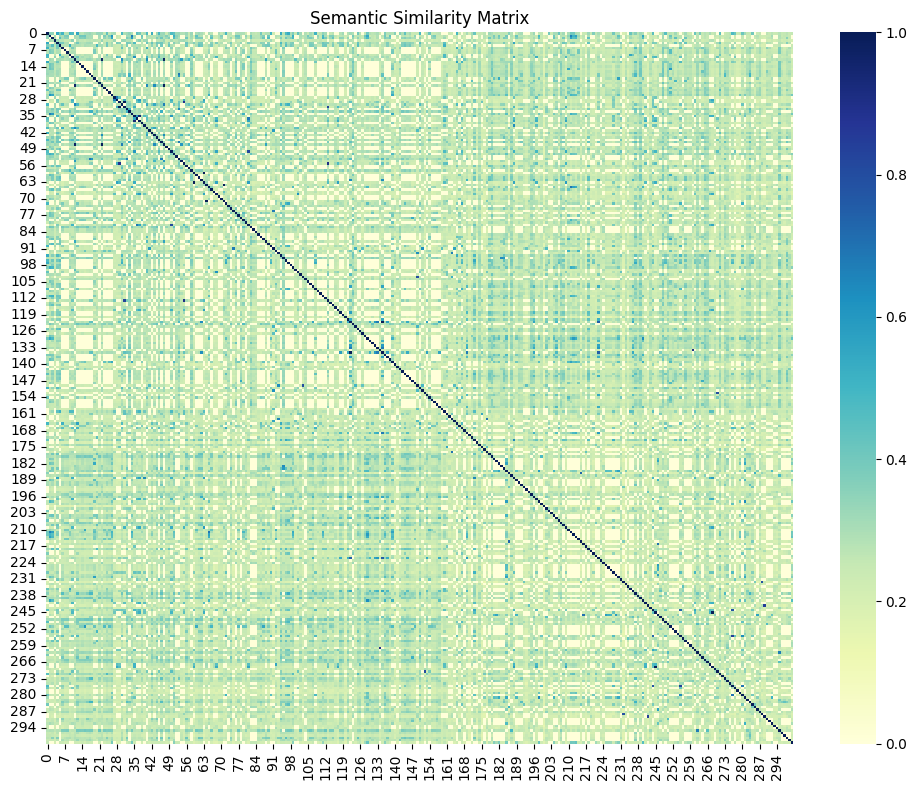

In [28]:
cross_db_similarity = outputs.semantic_similarity_matrix
all_pairs_similarity = build_semantic_similarity_matrix(
    semantic_demo_results,
    cross_source_only=False,
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cross_db_similarity, cmap="YlGnBu", vmin=0, vmax=1, linewidths=0, ax=axes[0])
axes[0].set_title("Semantic Similarity Matrix (Cross-Database Workflow View)")

sns.heatmap(all_pairs_similarity, cmap="YlGnBu", vmin=0, vmax=1, linewidths=0, ax=axes[1])
axes[1].set_title("Semantic Similarity Matrix (All-Pairs Diagnostic View)")

plt.tight_layout()
plt.show()


In [29]:
saved = save_default_visuals(
    outputs,
    "/Users/ranaezzeddine/Desktop/CrossEnrich/results",
    prefix="tp53_small",
)

saved



{'database_agreement_panels': '/Users/ranaezzeddine/Desktop/CrossEnrich/results/tp53_small_database_agreement_panels.png',
 'source_pair_ranking': '/Users/ranaezzeddine/Desktop/CrossEnrich/results/tp53_small_source_pair_ranking.png',
 'top_consensus_clusters': '/Users/ranaezzeddine/Desktop/CrossEnrich/results/tp53_small_top_consensus_clusters.png',
 'cluster_network': '/Users/ranaezzeddine/Desktop/CrossEnrich/results/tp53_small_cluster_network.png'}

In [30]:
# Optional: inspect the main internal objects directly
print("Standardized results preview")
display(outputs.standardized_results.head(20))

print("Clustered terms preview")
display(outputs.clustered_terms.head(20))



Standardized results preview


,description,effective_domain_size,intersection_size,intersections,name,native,p_value,parents,precision,query,...,source,term_size,evidences,canonical_source,standardized_name,resolved_name,term_tokens,intersection_genes,parent_terms,rank_within_source
0,p53 signaling pathway,8716,20,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",p53 signaling pathway,KEGG:04115,4.790777e-39,[KEGG:00000],0.909091,query_1,...,KEGG,75,"[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG...",KEGG,p53 signaling pathway,p53 signaling pathway,"(p53, signaling, pathway)","(TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...","(KEGG:00000,)",1
1,DNA damage response,8899,19,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",DNA damage response,WP:WP707,6.570686e-36,[WP:000000],0.826087,query_1,...,WP,69,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP...",WP,dna damage response,dna damage response,"(dna, damage, response)","(TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...","(WP:000000,)",1
2,miRNA regulation of DNA damage response,8899,19,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",miRNA regulation of DNA damage response,WP:WP1530,2.257520e-35,[WP:000000],0.826087,query_1,...,WP,73,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP...",WP,mirna regulation of dna damage response,mirna regulation of dna damage response,"(mirna, regulation, dna, damage, response)","(TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...","(WP:000000,)",2
3,Platinum drug resistance,8716,13,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, FAS, A...",Platinum drug resistance,KEGG:01524,1.238753e-20,[KEGG:00000],0.590909,query_1,...,KEGG,74,"[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG...",KEGG,platinum drug resistance,platinum drug resistance,"(platinum, drug, resistance)","(TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, FAS, A...","(KEGG:00000,)",2
4,miRNA regulation of p53 pathway in prostate ca...,8899,11,"[TP53, MDM2, BAX, BBC3, PMAIP1, TNFRSF10B, APA...",miRNA regulation of p53 pathway in prostate ca...,WP:WP3982,2.331874e-20,[WP:000000],0.478261,query_1,...,WP,31,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP...",WP,mirna regulation of p53 pathway in prostate ca...,mirna regulation of p53 pathway in prostate ca...,"(mirna, regulation, p53, pathway, prostate, ca...","(TP53, MDM2, BAX, BBC3, PMAIP1, TNFRSF10B, APA...","(WP:000000,)",3
5,Transcriptional Regulation by TP53,11056,17,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",Transcriptional Regulation by TP53,REAC:R-HSA-3700989,5.101278e-20,[REAC:R-HSA-212436],0.809524,query_1,...,REAC,356,"[[REAC], [REAC], [REAC], [REAC], [REAC], [REAC...",REAC,transcriptional regulation by tp53,transcriptional regulation by tp53,"(transcriptional, regulation, by, tp53)","(TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...","(REAC:R-HSA-212436,)",1
6,"""The series of molecular signals in which an i...",20972,15,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, RRM2B,...",intrinsic apoptotic signaling pathway,GO:0097193,2.465306e-19,"[GO:0035556, GO:0097190]",0.652174,query_1,...,GO:BP,318,"[[IDA, IMP, ISS, TAS, IEA], [IMP], [TAS, IEA],...",GO:BP,intrinsic apoptotic signaling pathway,intrinsic apoptotic signaling pathway,"(intrinsic, apoptotic, signaling, pathway)","(TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, RRM2B,...","(GO:0035556, GO:0097190)",1
7,"""Any process that results in a change in state...",20972,15,"[TP53, MDM2, CDKN1A, BAX, BBC3, GADD45A, FAS, ...",cellular response to abiotic stimulus,GO:0071214,4.970749e-19,"[GO:0009628, GO:0104004]",0.652174,query_1,...,GO:BP,333,"[[IDA, IMP, IEA], [IDA], [IMP, ISS, IEA], [IEA...",GO:BP,cellular response to abiotic stimulus,cellular response to abiotic stimulus,"(cellular, response, abiotic, stimulus)","(TP53, MDM2, CDKN1A, BAX, BBC3, GADD45A, FAS, ...","(GO:0009628, GO:0104004)",2
8,"""Any process that results in a change in state...",20972,15,"[TP53, MDM2, CDKN1A, BAX, BBC3, GADD45A, FAS, ...",cellular response to environmental stimulus,GO:0104004,4.970749e-19,[GO:0051716],0.652174,query_1,...,GO:BP,333,"[[ID

Clustered terms preview


,description,effective_domain_size,intersection_size,intersections,name,native,p_value,parents,precision,query,...,canonical_source,standardized_name,resolved_name,term_tokens,intersection_genes,parent_terms,rank_within_source,cluster_id,semantic_similarity_max,cluster_label
0,p53 signaling pathway,8716,20,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",p53 signaling pathway,KEGG:04115,4.790777e-39,[KEGG:00000],0.909091,query_1,...,KEGG,p53 signaling pathway,p53 signaling pathway,"(p53, signaling, pathway)","(TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...","(KEGG:00000,)",1,54,0.550305,p53 signaling pathway
1,DNA damage response,8899,19,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",DNA damage response,WP:WP707,6.570686e-36,[WP:000000],0.826087,query_1,...,WP,dna damage response,dna damage response,"(dna, damage, response)","(TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...","(WP:000000,)",1,41,0.678231,dna damage response
2,miRNA regulation of DNA damage response,8899,19,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",miRNA regulation of DNA damage response,WP:WP1530,2.257520e-35,[WP:000000],0.826087,query_1,...,WP,mirna regulation of dna damage response,mirna regulation of dna damage response,"(mirna, regulation, dna, damage, response)","(TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...","(WP:000000,)",2,41,0.593288,dna damage response
3,Platinum drug resistance,8716,13,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, FAS, A...",Platinum drug resistance,KEGG:01524,1.238753e-20,[KEGG:00000],0.590909,query_1,...,KEGG,platinum drug resistance,platinum drug resistance,"(platinum, drug, resistance)","(TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, FAS, A...","(KEGG:00000,)",2,16,0.417699,platinum drug resistance
4,miRNA regulation of p53 pathway in prostate ca...,8899,11,"[TP53, MDM2, BAX, BBC3, PMAIP1, TNFRSF10B, APA...",miRNA regulation of p53 pathway in prostate ca...,WP:WP3982,2.331874e-20,[WP:000000],0.478261,query_1,...,WP,mirna regulation of p53 pathway in prostate ca...,mirna regulation of p53 pathway in prostate ca...,"(mirna, regulation, p53, pathway, prostate, ca...","(TP53, MDM2, BAX, BBC3, PMAIP1, TNFRSF10B, APA...","(WP:000000,)",3,54,0.551282,p53 signaling pathway
5,Transcriptional Regulation by TP53,11056,17,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",Transcriptional Regulation by TP53,REAC:R-HSA-3700989,5.101278e-20,[REAC:R-HSA-212436],0.809524,query_1,...,REAC,transcriptional regulation by tp53,transcriptional regulation by tp53,"(transcriptional, regulation, by, tp53)","(TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...","(REAC:R-HSA-212436,)",1,64,0.538809,transcriptional regulation by tp53
6,"""The series of molecular signals in which an i...",20972,15,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, RRM2B,...",intrinsic apoptotic signaling pathway,GO:0097193,2.465306e-19,"[GO:0035556, GO:0097190]",0.652174,query_1,...,GO:BP,intrinsic apoptotic signaling pathway,intrinsic apoptotic signaling pathway,"(intrinsic, apoptotic, signaling, pathway)","(TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, RRM2B,...","(GO:0035556, GO:0097190)",1,54,0.525786,p53 signaling pathway
7,"""Any process that results in a change in state...",20972,15,"[TP53, MDM2, CDKN1A, BAX, BBC3, GADD45A, FAS, ...",cellular response to abiotic stimulus,GO:0071214,4.970749e-19,"[GO:0009628, GO:0104004]",0.652174,query_1,...,GO:BP,cellular response to abiotic stimulus,cellular response to abiotic stimulus,"(cellular, response, abiotic, stimulus)","(TP53, MDM2, CDKN1A, BAX, BBC3, GADD45A, FAS, ...","(GO:0009628, GO:0104004)",2,17,0.456079,cellular response to abiotic stimulus
8,"""Any process that results in a change in state...",20972,15,"[TP53, MDM2, CDKN1A, BAX, BBC3, GADD45A, FAS, ...",cellular response to environmental stimulus,GO:0104004,4.970749e-19,[GO:0051716],0.652174,query_1,...,GO:BP,cellular response to environmental stimulus,cellular response to environmental stimulus,"(cellular, response, environmental, stimulus)","(TP53, MDM2, CDKN1A, BAX, BBC

In [31]:
# Optional: compare the strongest source pairs quickly
display(
    pair_summary[[
        "source_pair",
        "term_jaccard",
        "gene_jaccard",
        "spearman",
        "cluster_consistency",
        "strongest_signal",
    ]].head(10)
)



,source_pair,term_jaccard,gene_jaccard,spearman,cluster_consistency,strongest_signal
0,KEGG-WP,0.051282,0.815816,0.606257,0.652174,gene
1,REAC-GO:BP,0.000000,0.629150,0.622179,0.629630,semantic
2,WP-REAC,0.006944,0.694207,0.467222,0.545455,gene
3,WP-GO:BP,0.006757,0.627662,0.732153,0.406780,rank
4,KEGG-REAC,0.007752,0.696046,0.401626,0.396552,gene
5,GO:CC-GO:MF,0.000000,0.563570,0.000000,0.285714,gene
6,KEGG-GO:BP,0.000000,0.655292,0.375283,0.253968,gene
7,GO:BP-GO:CC,0.000000,0.686358,0.163141,0.232558,gene
8,REAC-GO:CC,0.000000,0.759131,0.123629,0.222222,gene
9,WP-GO:CC,0.000000,0.575574,-0.221295,0.190476,gene


In [32]:
# Optional: inspect the semantic similarity heatmap with annotations on a smaller slice
preview_size = min(20, len(outputs.semantic_similarity_matrix))
display(outputs.semantic_similarity_matrix.iloc[:preview_size, :preview_size].round(2))



,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1.00,0.35,0.35,0.00,0.55,0.38,0.50,0.27,0.28,0.49,0.48,0.00,0.55,0.28,0.27,0.31,0.32,0.33,0.30,0.28
1,0.35,1.00,0.00,0.31,0.00,0.34,0.30,0.38,0.39,0.00,0.00,0.32,0.30,0.41,0.41,0.41,0.31,0.31,0.30,0.00
2,0.35,0.00,1.00,0.29,0.00,0.46,0.31,0.36,0.36,0.00,0.00,0.30,0.30,0.37,0.36,0.38,0.31,0.30,0.30,0.00
3,0.00,0.31,0.29,1.00,0.31,0.27,0.27,0.25,0.25,0.27,0.36,0.00,0.29,0.26,0.26,0.25,0.27,0.27,0.27,0.28
4,0.55,0.00,0.00,0.31,1.00,0.41,0.39,0.29,0.30,0.00,0.00,0.30,0.40,0.30,0.28,0.29,0.31,0.32,0.30,0.00
5,0.38,0.34,0.46,0.27,0.41,1.00,0.28,0.28,0.29,0.54,0.29,0.31,0.29,0.29,0.27,0.30,0.29,0.29,0.28,0.28
6,0.50,0.30,0.31,0.27,0.39,0.28,1.00,0.00,0.00,0.26,0.38,0.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.29
7,0.27,0.38,0.36,0.25,0.29,0.28,0.00,1.00,0.00,0.26,0.28,0.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.38
8,0.28,0.39,0.36,0.25,0.30,0.29,0.00,0.00,1.00,0.27,0.30,0.29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.39
9,0.49,0.00,0.00,0.27,0.00,0.54,0.26,0.26,0.27,1.00,0.00,0.32,0.27,0.28,0.25,0.29,0.28,0.28,0.27,0.00
